Installing the required libraries

In [2]:
pip install pandas numpy matplotlib scikit-learn tensorflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
pip install --upgrade pip

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----------------- ---------------------- 0.8/1.8 MB 16.9 MB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 12.4 MB/s  0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 26.1.2
    Uninstalling pip-26.1.2:
      Successfully uninstalled pip-26.1.2
Note: you may need to restart the kernel to use updated packages.


Importing required libraries

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
# TensorFlow libraries for GAN implementation
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU
from tensorflow.keras.optimizers import Adam

Load the Dataset

In [21]:
df = pd.read_excel("Lab1_Dataset.xlsx")
df

,design_id,climate_zone,orientation,shape_type,window_to_wall_ratio,shading_depth_m,roof_insulation_cm,cross_ventilation_score,daylight_score,green_cover_pct,floor_area_sqm,estimated_energy_use_kwh_per_sqm_year,efficiency_label
0,D001,Warm-Humid,South-West,Courtyard,0.46,1.89,3.0,7,9,46,448,69.55,Medium
1,D002,Temperate,East-West,Linear,0.50,0.53,9.2,1,6,58,275,88.32,Low
2,D003,Composite,North-South,Atrium,0.38,0.32,4.9,6,4,43,309,74.62,Medium
3,D004,Composite,East-West,Compact,0.46,1.53,6.7,3,9,45,490,81.86,Low
4,D005,Hot-Dry,North-South,Compact,0.44,1.23,5.5,10,5,53,382,52.93,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,D236,Composite,South-West,Linear,0.61,0.89,12.5,1,3,27,495,100.92,Low
236,D237,Warm-Humid,North-East,Atrium,0.57,1.13,13.7,5,7,23,524,73.39,Medium
237,D238,Hot-Dry,South-West,Compact,0.63,0.28,13.6,4,5,13,241,77.20,Medium
238,D239,Composite,South-West,Courtyard,0.21,0.50,11.0,8,2,39,151,60.72,Medium


Data Inspection

In [24]:
# Check number of rows and columns
print("Shape of dataset:", df.shape)
# Check column names
print("\nColumn names:")
print(df.columns)
# Check data types and basic information
print("\nDataset information:")
print(df.info())

Shape of dataset: (240, 13)

Column names:
Index(['design_id', 'climate_zone', 'orientation', 'shape_type',
       'window_to_wall_ratio', 'shading_depth_m', 'roof_insulation_cm',
       'cross_ventilation_score', 'daylight_score', 'green_cover_pct',
       'floor_area_sqm', 'estimated_energy_use_kwh_per_sqm_year',
       'efficiency_label'],
      dtype='object')

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 13 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   design_id                              240 non-null    object 
 1   climate_zone                           240 non-null    object 
 2   orientation                            240 non-null    object 
 3   shape_type                             240 non-null    object 
 4   window_to_wall_ratio                   240 non-null    float64
 5   shading_depth_m          

Count efficiency labels

In [27]:
print("\nEfficiency label counts:")
print(df["efficiency_label"].value_counts())


Efficiency label counts:
efficiency_label
Medium    158
Low        59
High       23
Name: count, dtype: int64


Plot the count of efficiency labels

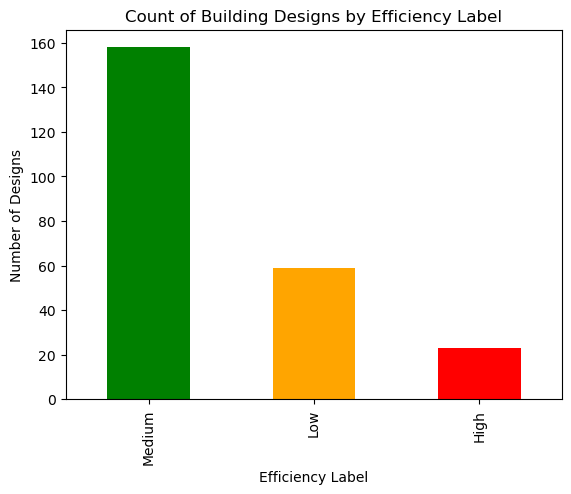

In [30]:
df["efficiency_label"].value_counts().plot(kind="bar", color=["green", "orange", "red"])
plt.title("Count of Building Designs by Efficiency Label")
plt.xlabel("Efficiency Label")
plt.ylabel("Number of Designs")
plt.show()

Separate categorical and numerical columns

In [35]:
categorical_cols = ["climate_zone", "orientation", "shape_type"]
numerical_cols = [
    "window_to_wall_ratio",
    "shading_depth_m",
    "roof_insulation_cm",
    "cross_ventilation_score",
    "daylight_score",
    "green_cover_pct",
    "floor_area_sqm"
]

Convert categorical columns into one-hot encoded numeric columns

In [38]:
encoder = OneHotEncoder(sparse_output=False)
encoded_data = encoder.fit_transform(df[categorical_cols])
# Convert the encoded output into a DataFrame
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(categorical_cols))
# Display first few rows
print("\nEncoded categorical data:")
print(encoded_df.head())


Encoded categorical data:
   climate_zone_Composite  climate_zone_Hot-Dry  climate_zone_Temperate  \
0                     0.0                   0.0                     0.0   
1                     0.0                   0.0                     1.0   
2                     1.0                   0.0                     0.0   
3                     1.0                   0.0                     0.0   
4                     0.0                   1.0                     0.0   

   climate_zone_Warm-Humid  orientation_East-West  orientation_North-East  \
0                      1.0                    0.0                     0.0   
1                      0.0                    1.0                     0.0   
2                      0.0                    0.0                     0.0   
3                      0.0                    1.0                     0.0   
4                      0.0                    0.0                     0.0   

   orientation_North-South  orientation_South-West  shape_t

Scale numerical columns between 0 and 1

In [41]:
scaler = MinMaxScaler()
scaled_numerical = scaler.fit_transform(df[numerical_cols])
# Convert to DataFrame
scaled_numerical_df = pd.DataFrame(scaled_numerical, columns=numerical_cols)
# Display first few rows
print("\nScaled numerical data:")
print(scaled_numerical_df.head())


Scaled numerical data:
   window_to_wall_ratio  shading_depth_m  roof_insulation_cm  \
0              0.612245         0.943820            0.075630   
1              0.693878         0.179775            0.596639   
2              0.448980         0.061798            0.235294   
3              0.612245         0.741573            0.386555   
4              0.571429         0.573034            0.285714   

   cross_ventilation_score  daylight_score  green_cover_pct  floor_area_sqm  
0                 0.666667        0.888889         0.745455        0.680761  
1                 0.000000        0.555556         0.963636        0.315011  
2                 0.555556        0.333333         0.690909        0.386892  
3                 0.222222        0.888889         0.727273        0.769556  
4                 1.000000        0.444444         0.872727        0.541226  


Combine encoded categorical data and scaled numerical data

In [44]:
processed_data = pd.concat([encoded_df, scaled_numerical_df], axis=1)
# Display processed data
print("\nProcessed data:")
print(processed_data.head())
# Convert processed data into NumPy array for GAN training
X_train = processed_data.values


Processed data:
   climate_zone_Composite  climate_zone_Hot-Dry  climate_zone_Temperate  \
0                     0.0                   0.0                     0.0   
1                     0.0                   0.0                     1.0   
2                     1.0                   0.0                     0.0   
3                     1.0                   0.0                     0.0   
4                     0.0                   1.0                     0.0   

   climate_zone_Warm-Humid  orientation_East-West  orientation_North-East  \
0                      1.0                    0.0                     0.0   
1                      0.0                    1.0                     0.0   
2                      0.0                    0.0                     0.0   
3                      0.0                    1.0                     0.0   
4                      0.0                    0.0                     0.0   

   orientation_North-South  orientation_South-West  shape_type_Atrium

Define GAN Parameters

In [47]:
data_dim = X_train.shape[1]
# Random noise vector size
latent_dim = 16

Create Generator Model

In [52]:
generator = Sequential([
    Dense(32, input_dim=latent_dim),
    LeakyReLU(alpha=0.2),
    Dense(64),
    LeakyReLU(alpha=0.2),
    Dense(data_dim, activation='sigmoid')
])
generator.summary()

C:\Users\rampa\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\rampa\anaconda3\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 32)                  │             544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_2 (LeakyReLU)            │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_3 (LeakyReLU)            │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 19)                  │           1,235 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,891 (15.20 KB)

 Trainable params: 3,891 (15.20 KB)

 Non-trainable params: 0 (0.00 B)

Create Discriminator Model

In [55]:
discriminator = Sequential([
    Dense(64, input_dim=data_dim),
    LeakyReLU(alpha=0.2),
    Dense(32),
    LeakyReLU(alpha=0.2),
    Dense(1, activation='sigmoid')
])
discriminator.compile(
    optimizer=Adam(0.0002),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
discriminator.summary()

C:\Users\rampa\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\rampa\anaconda3\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                      │ (None, 64)                  │           1,280 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_4 (LeakyReLU)            │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_5 (LeakyReLU)            │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,393 (13.25 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 0 (0.00 B)

Creating GAN Model

In [58]:
# Combine Generator and Discriminator
discriminator.trainable = False
gan = Sequential([
    generator,
    discriminator
])
gan.compile(
    optimizer=Adam(0.0002),
    loss='binary_crossentropy'
)

Training the GAN Model

In [61]:
# Train the GAN
epochs = 500
batch_size = 16
for epoch in range(epochs):
    # Select random real samples
    idx = np.random.randint(0, X_train.shape[0], batch_size)
    real_samples = X_train[idx]
    # Generate fake samples
    noise = np.random.normal(0, 1, (batch_size, latent_dim))
    fake_samples = generator.predict(noise, verbose=0)
    # Labels
    real_labels = np.ones((batch_size, 1))
    fake_labels = np.zeros((batch_size, 1))
    # Train Discriminator
    discriminator.trainable = True
    discriminator.train_on_batch(real_samples, real_labels)
    discriminator.train_on_batch(fake_samples, fake_labels)
    # Train Generator
    discriminator.trainable = False
    noise = np.random.normal(0, 1, (batch_size, latent_dim))
    gan.train_on_batch(noise, real_labels)
    # Print progress
    if epoch % 100 == 0:
        print(f"Epoch {epoch} completed")

Epoch 0 completed
Epoch 100 completed
Epoch 200 completed
Epoch 300 completed
Epoch 400 completed


Generating synthetic design

In [64]:
noise = np.random.normal(0, 1, (20, latent_dim))
generated_samples = generator.predict(noise)
# Convert generated output into DataFrame
synthetic_data = pd.DataFrame(
    generated_samples,
    columns=processed_data.columns
)
print("\nGAN Generated Synthetic Designs:")
print(synthetic_data.head())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step

GAN Generated Synthetic Designs:
   climate_zone_Composite  climate_zone_Hot-Dry  climate_zone_Temperate  \
0                0.059432              0.029733                0.036517   
1                0.039555              0.040717                0.015134   
2                0.135471              0.076304                0.139587   
3                0.088356              0.050417                0.109819   
4                0.069934              0.091386                0.094284   

   climate_zone_Warm-Humid  orientation_East-West  orientation_North-East  \
0                 0.100207               0.058062                0.043191   
1                 0.227387               0.063068                0.127478   
2                 0.161573               0.055015                0.093006   
3                 0.253745               0.102710                0.065623   
4                 0.119243               0.050903                0.075294   

   orientatio

Convert scaled values back to original units

In [67]:
synthetic_numerical_original = scaler.inverse_transform(synthetic_data[numerical_cols])
# Convert into DataFrame
synthetic_numerical_df = pd.DataFrame(synthetic_numerical_original, columns=numerical_cols)

Decoding

In [70]:
# Extract the categorical part of the generated data
synthetic_categorical_part = synthetic_data[encoded_df.columns]
# Decode the most likely category for each row
decoded_categories = []
for i in range(len(synthetic_categorical_part)):
    decoded = {}
 
    for col in categorical_cols:
        category_names = [c for c in encoded_df.columns if c.startswith(col + "_")]
        category_values = synthetic_categorical_part.iloc[i][category_names].values
        max_index = np.argmax(category_values)
        decoded[col] = category_names[max_index].replace(col + "_", "")
   
    decoded_categories.append(decoded)
decoded_df = pd.DataFrame(decoded_categories)
print("\nDecoded generated categories:")
print(decoded_df.head())


Decoded generated categories:
  climate_zone orientation shape_type
0   Warm-Humid  South-West  Courtyard
1   Warm-Humid  North-East     Atrium
2   Warm-Humid  South-West  Courtyard
3   Warm-Humid  South-West  Courtyard
4   Warm-Humid  South-West    Compact


Combine decoded categories with restored numerical values

In [73]:
generated_designs = pd.concat([decoded_df, synthetic_numerical_df], axis=1)
# Round values for better readability

generated_designs["window_to_wall_ratio"] = generated_designs["window_to_wall_ratio"].round(2)
generated_designs["shading_depth_m"] = generated_designs["shading_depth_m"].round(2)
generated_designs["roof_insulation_cm"] = generated_designs["roof_insulation_cm"].round(1)
generated_designs["green_cover_pct"] = generated_designs["green_cover_pct"].round(0)
generated_designs["floor_area_sqm"] = generated_designs["floor_area_sqm"].round(0)
print("\nGenerated design options:")
print(generated_designs.head(10))


Generated design options:
  climate_zone orientation shape_type  window_to_wall_ratio  shading_depth_m  \
0   Warm-Humid  South-West  Courtyard                  0.25             0.42   
1   Warm-Humid  North-East     Atrium                  0.20             0.47   
2   Warm-Humid  South-West  Courtyard                  0.24             1.00   
3   Warm-Humid  South-West  Courtyard                  0.20             0.79   
4   Warm-Humid  South-West    Compact                  0.31             0.86   
5   Warm-Humid  South-West  Courtyard                  0.20             0.59   
6   Warm-Humid  South-West     Atrium                  0.19             0.97   
7   Warm-Humid  South-West    Compact                  0.31             0.88   
8   Warm-Humid  South-West  Courtyard                  0.18             0.71   
9   Warm-Humid  South-West  Courtyard                  0.18             0.39   

   roof_insulation_cm  cross_ventilation_score  daylight_score  \
0                 2.4     

Function to estimate energy use

In [76]:
def estimate_energy(row):
    energy = 95
    climate_adj = {
        "Hot-Dry": 8,
        "Warm-Humid": 10,
        "Composite": 12,
        "Temperate": 6
    }
    orientation_adj = {
        "North-South": -5,
        "East-West": 8,
        "North-East": 0,
        "South-West": 4
    }
    shape_adj = {
        "Compact": -6,
        "Courtyard": -2,
        "Linear": 5,
        "Atrium": 1
    }
    energy += climate_adj[row["climate_zone"]]
    energy += orientation_adj[row["orientation"]]
    energy += shape_adj[row["shape_type"]]
    energy += (row["window_to_wall_ratio"] - 0.30) * 40
    energy -= row["shading_depth_m"] * 6
    energy -= row["roof_insulation_cm"] * 1.4
    energy -= row["cross_ventilation_score"] * 1.8
    energy -= row["daylight_score"] * 1.1
    energy -= row["green_cover_pct"] * 0.18
    energy += (row["floor_area_sqm"] - 250) * 0.015
    return round(energy, 2)
# Apply energy calculation
generated_designs["estimated_energy_use_kwh_per_sqm_year"] = generated_designs.apply(estimate_energy, axis=1)
# Label the efficiency level
def label_efficiency(energy):
    if energy <= 55:
        return "High"
    elif energy <= 80:
        return "Medium"
    else:
        return "Low"
generated_designs["efficiency_label"] = generated_designs["estimated_energy_use_kwh_per_sqm_year"].apply(label_efficiency)
print("\nGenerated designs with energy estimates:")
print(generated_designs.head(10))


Generated designs with energy estimates:
  climate_zone orientation shape_type  window_to_wall_ratio  shading_depth_m  \
0   Warm-Humid  South-West  Courtyard                  0.25             0.42   
1   Warm-Humid  North-East     Atrium                  0.20             0.47   
2   Warm-Humid  South-West  Courtyard                  0.24             1.00   
3   Warm-Humid  South-West  Courtyard                  0.20             0.79   
4   Warm-Humid  South-West    Compact                  0.31             0.86   
5   Warm-Humid  South-West  Courtyard                  0.20             0.59   
6   Warm-Humid  South-West     Atrium                  0.19             0.97   
7   Warm-Humid  South-West    Compact                  0.31             0.88   
8   Warm-Humid  South-West  Courtyard                  0.18             0.71   
9   Warm-Humid  South-West  Courtyard                  0.18             0.39   

   roof_insulation_cm  cross_ventilation_score  daylight_score  \
0          

Sort from most energy-efficient to least energy-efficient

In [79]:
best_designs = generated_designs.sort_values(by="estimated_energy_use_kwh_per_sqm_year")
print("\nTop 5 best generated designs:")
print(best_designs.head(5))



Top 5 best generated designs:
   climate_zone orientation shape_type  window_to_wall_ratio  shading_depth_m  \
17   Warm-Humid  North-East     Atrium                  0.23             0.79   
14   Warm-Humid  South-West  Courtyard                  0.17             1.06   
12   Warm-Humid  South-West     Atrium                  0.23             0.90   
16   Warm-Humid  South-West  Courtyard                  0.19             1.18   
3    Warm-Humid  South-West  Courtyard                  0.20             0.79   

    roof_insulation_cm  cross_ventilation_score  daylight_score  \
17                 4.3                 8.119242        3.437394   
14                 2.7                 9.002438        2.051868   
12                 4.7                 8.423687        4.352984   
16                 3.2                 8.995356        2.094628   
3                  3.2                 9.140885        2.981447   

    green_cover_pct  floor_area_sqm  estimated_energy_use_kwh_per_sqm_year  \
1

Plot estimated energy use of generated designs

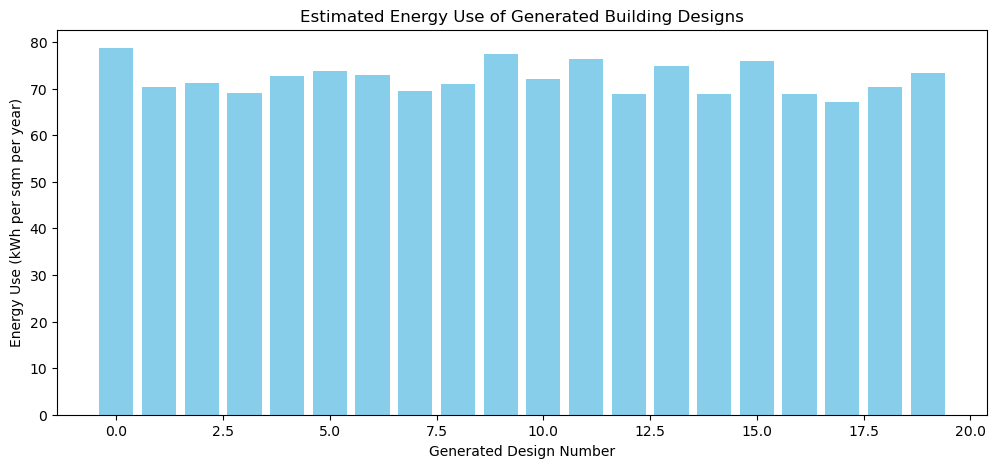

In [82]:
plt.figure(figsize=(12, 5))
plt.bar(range(len(generated_designs)), generated_designs["estimated_energy_use_kwh_per_sqm_year"], color="skyblue")
plt.title("Estimated Energy Use of Generated Building Designs")
plt.xlabel("Generated Design Number")
plt.ylabel("Energy Use (kWh per sqm per year)")
plt.show()

In [84]:
generated_designs.to_excel("generated_energy_efficient_building_designs.xlsx", index=False)
print("\nFile saved successfully as generated_energy_efficient_building_designs.xlsx")


File saved successfully as generated_energy_efficient_building_designs.xlsx
